<div align='center' style='padding:50px 30px 40px; border-bottom: 2px solid #dee2e6;'>

<img src='https://img.shields.io/badge/Python-3.10-blue?style=flat-square&logo=python' />
&nbsp;<img src='https://img.shields.io/badge/Scikit--Learn-1.3-orange?style=flat-square&logo=scikit-learn' />
&nbsp;<img src='https://img.shields.io/badge/Streamlit-App-red?style=flat-square&logo=streamlit' />
&nbsp;<img src='https://img.shields.io/badge/Status-Complete-brightgreen?style=flat-square' />

<br/><br/>

# 📡 Telco Customer Churn Prediction
## Final Project Report

<br/>

| | |
|:---|:---|
| **Program** | IBT × GGateway Data Science Bootcamp |
| **Mentors** | Daniel Rubi &nbsp;·&nbsp; Dr. Ramiz |
| **Date** | March 2026 |
| **Repository** | [github.com/linda-bsharat/telco-customer-churn-prediction](https://github.com/linda-bsharat/telco-customer-churn-prediction) |

<br/>

### 👥 Team

| | | |
|:---:|:---:|:---:|
| Ruba Halabi | Linda Bsharat | Ibrahim Kilani |
| Naser Abdalsalam | Ahmad Abu Alhlawa | |

</div>

---
## 📋 Table of Contents

1. [Project Overview](#1-project-overview)
2. [Dataset Description](#2-dataset-description)
3. [Data Cleaning & Preprocessing](#3-data-cleaning--preprocessing)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Model Building & Evaluation](#5-model-building--evaluation)
6. [Final Results](#6-final-results)
7. [Streamlit Application](#7-streamlit-application)
8. [Conclusions & Recommendations](#8-conclusions--recommendations)
9. [References](#9-references)

---

## 1. Project Overview

### 1.1 Background

Customer churn — the phenomenon of customers discontinuing use of a service — is among the most critical business problems in the telecommunications industry. Acquiring a new customer costs **5 to 7 times more** than retaining an existing one, making proactive churn detection a high-value application of machine learning.

This project delivers a **complete end-to-end machine learning pipeline** that cleans raw data, uncovers actionable patterns through visual analysis, trains and compares multiple classifiers, and deploys results in an interactive Streamlit application.

### 1.2 Objective

Build a binary classification model that predicts whether a telecom customer will churn (`1`) or stay (`0`), using demographic, service, and billing features — enabling the business to intervene before customers leave.

### 1.3 Success Criteria

| Metric | Target | Result | Status |
|:---|:---:|:---:|:---:|
| F1 Score | ≥ 0.70 | **0.7867** | ✅ |
| Recall | ≥ 0.80 | **89.6%** | ✅ |
| Accuracy | ≥ 0.75 | **77.0%** | ✅ |

> **Why Recall?** A missed churner (False Negative) costs the company a lost customer. A false alarm (False Positive) only costs a retention offer. Maximising Recall is therefore the primary business objective.

### 1.4 Project Architecture

```
Raw Data  ──►  01 · Data Cleaning & Feature Engineering
               ──►  02 · Exploratory Data Analysis
                    ──►  03 · Model Building & Evaluation
                         ──►  src/app.py · Streamlit Application
```

---

## 2. Dataset Description

### 2.1 Source

Based on the IBM Telco Customer Churn dataset, extended to 70,000 records to simulate a realistic production scale.

### 2.2 Feature Catalogue

| Category | Features |
|:---|:---|
| **Demographics** | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| **Account** | `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod` |
| **Phone** | `PhoneService`, `MultipleLines` |
| **Internet** | `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| **Billing** | `MonthlyCharges`, `TotalCharges` |
| **Engineered** | `IsNewCustomer`, `IsLongTermCustomer`, `AvgMonthlyCharge`, `TotalServices`, `HasInternet` |
| **Target** | `Churn` — `0` = Stayed · `1` = Churned |

---

## 3. Data Cleaning & Preprocessing

`notebooks/01_data_cleaning_and_eda.ipynb`

### 3.1 Raw Data Quality Issues

| Column | Problem | Resolution |
|:---|:---|:---|
| `gender` | 748 missing + labels `F/M/Man` | Mode fill + standardise |
| `SeniorCitizen` | Mixed `Yes/No/not senior` | Map to `1/0` |
| `PaymentMethod` | 3,569 missing + `BANK TRANSFER` variant | Mode fill + standardise |
| `tenure`, `MonthlyCharges` | Hundreds of nulls | Median fill |
| `TotalCharges` | 1,062 missing + 320 negatives | Imputed as `tenure × MonthlyCharges` |
| `Churn` | Mixed labels: `Yes/No/Y/N/CHURNED/Unknown` | Standardise to `1/0`; drop 54 `Unknown` |
| `Contract` | `M-M` abbreviation | Replaced with `Month-to-month` |
| `MultipleLines` | 1,320 rows with `PhoneService=1` but `"No phone service"` | Corrected to `"No"` |

### 3.2 Encoding Strategy

| Column | Method | Mapping |
|:---|:---|:---|
| 10 binary service columns | Map | `Yes→1`, `No→0` |
| `gender` | Map | `Male→1`, `Female→0` |
| `MultipleLines` | Ordinal | `0/1/2` |
| `InternetService` | Ordinal | `No=0`, `DSL=1`, `Fiber=2` |
| `Contract` | Ordinal | `Monthly=0`, `1yr=1`, `2yr=2` |
| `PaymentMethod` | One-Hot | 4 binary columns |

### 3.3 Feature Engineering

| Feature | Formula | Rationale |
|:---|:---|:---|
| `IsNewCustomer` | `tenure ≤ 6` | New customers churn more |
| `IsLongTermCustomer` | `tenure ≥ 48` | Long-term customers are loyal |
| `AvgMonthlyCharge` | `TotalCharges / (tenure + 1)` | Normalised billing signal |
| `TotalServices` | Sum of 7 service flags | Measures engagement depth |
| `HasInternet` | `InternetService ≠ 0` | Internet presence indicator |

### 3.4 Outlier Treatment

IQR method applied to `tenure`, `AvgMonthlyCharge`, `TotalServices`. No rows removed — extreme values **clipped** to preserve dataset integrity.


<div align='center'>
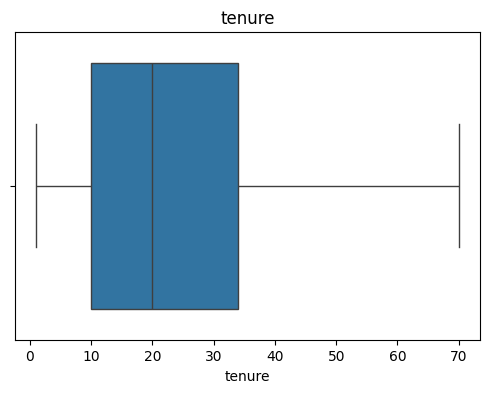
<br/><sub><i>Figure 1 — Boxplot: tenure (before clipping)</i></sub>
</div>

<div align='center'>
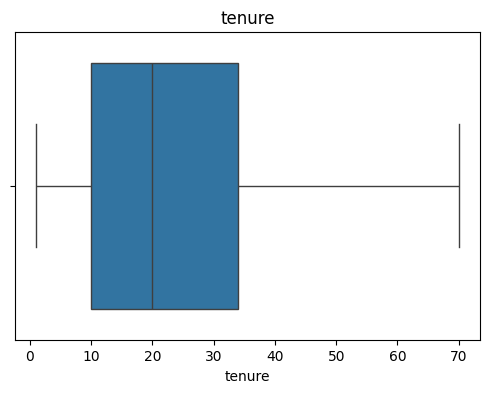
<br/><sub><i>Figure 2 — Boxplot: tenure (after clipping)</i></sub>
</div>

<div align='center'>
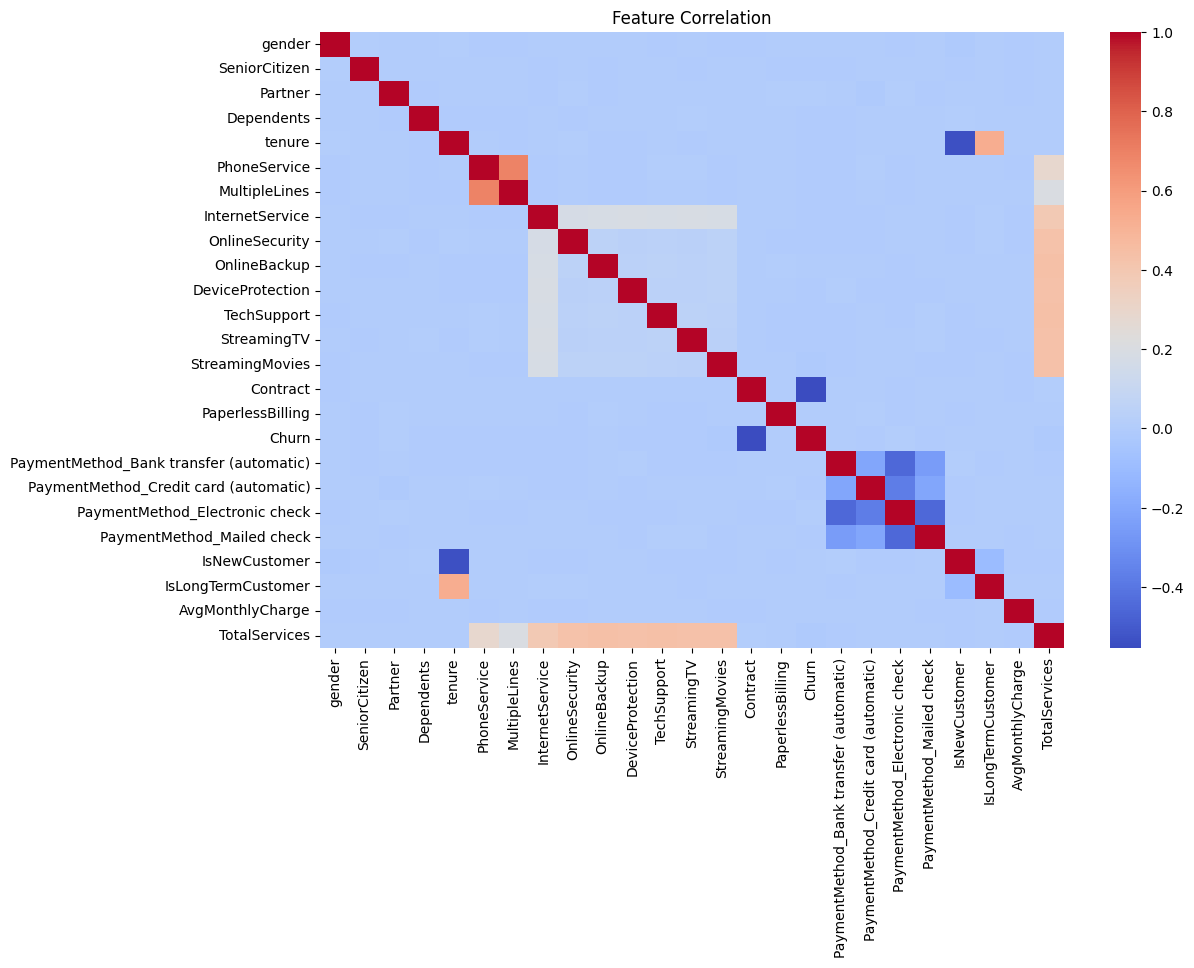
<br/><sub><i>Figure 3 — Feature Correlation Heatmap (post-cleaning)</i></sub>
</div>

### 3.5 Final Dataset Summary

| Property | Value |
|:---|:---|
| Records after cleaning | **67,376** |
| Features | **26** |
| Missing values | **0** |
| Churn distribution | 53.1% No Churn · 46.9% Churn |

---

## 4. Exploratory Data Analysis

`notebooks/02_eda_and_visualization.ipynb`

### 4.1 Target Variable Distribution

The dataset is **near-balanced** (53/47 split) — no resampling technique was required.


<div align='center'>
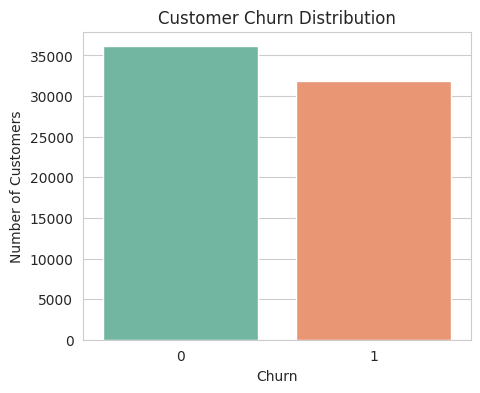
<br/><sub><i>Figure 4 — Customer Churn Distribution</i></sub>
</div>

### 4.2 Churn by Contract Type

Contract type is the **single strongest predictor** of churn. Month-to-month customers churn at ~70%, compared to just ~5% for two-year contract holders.


<div align='center'>
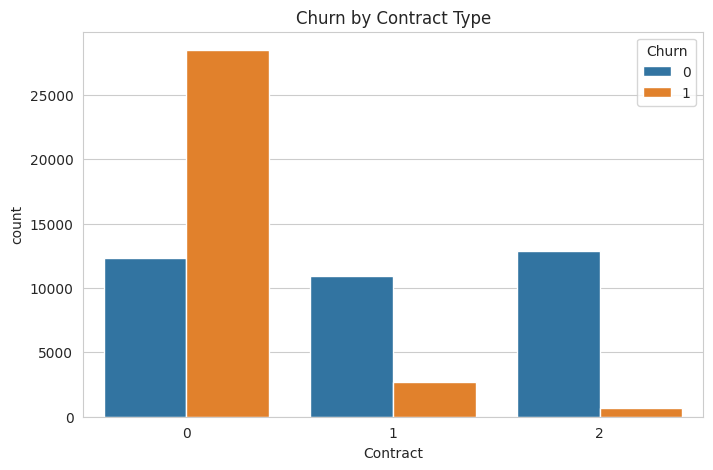
<br/><sub><i>Figure 5 — Churn Count by Contract Type</i></sub>
</div>

<div align='center'>
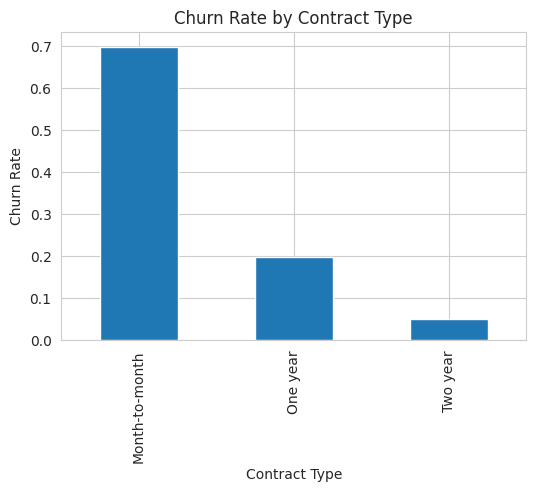
<br/><sub><i>Figure 6 — Churn Rate (%) by Contract Type</i></sub>
</div>

| Contract | Churn Rate |
|:---|:---:|
| Month-to-month | **69.8%** |
| One year | 19.9% |
| Two year | 5.0% |

> Incentivising customers to commit to longer contracts is the highest-leverage retention strategy available to the business.

### 4.3 Tenure vs Churn

Churn is heavily concentrated in the first 12 months. After that, loyalty increases sharply — making the **first year the most critical retention window**.


<div align='center'>
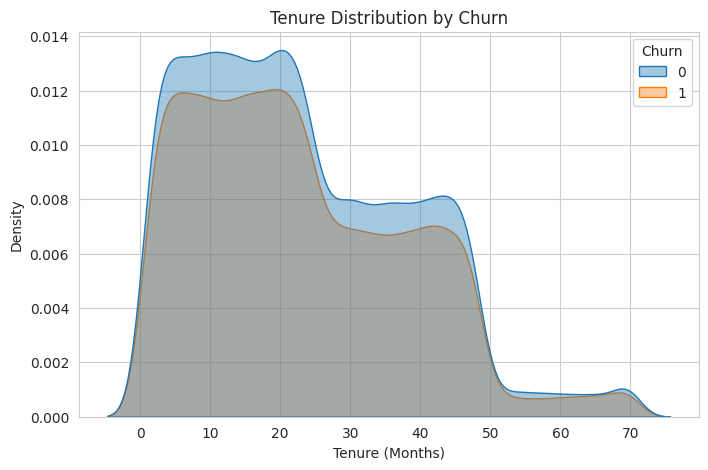
<br/><sub><i>Figure 7 — Tenure Distribution by Churn (KDE)</i></sub>
</div>

<div align='center'>
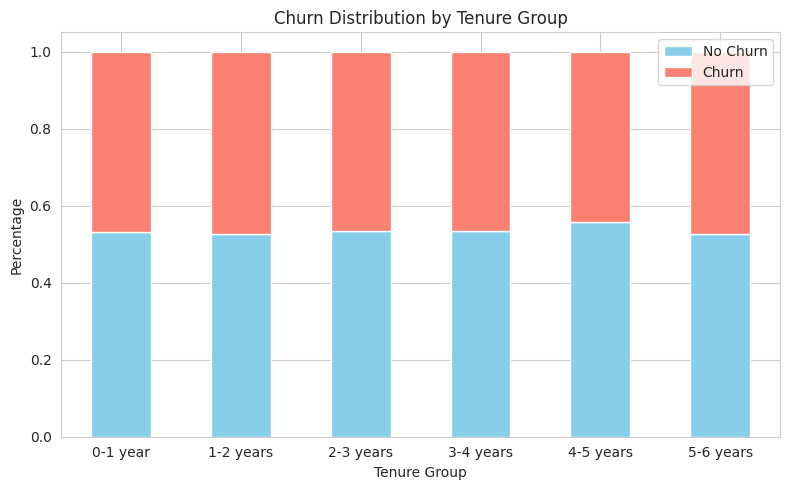
<br/><sub><i>Figure 8 — Churn Rate by Tenure Group</i></sub>
</div>

### 4.4 Feature Correlation Heatmap


<div align='center'>
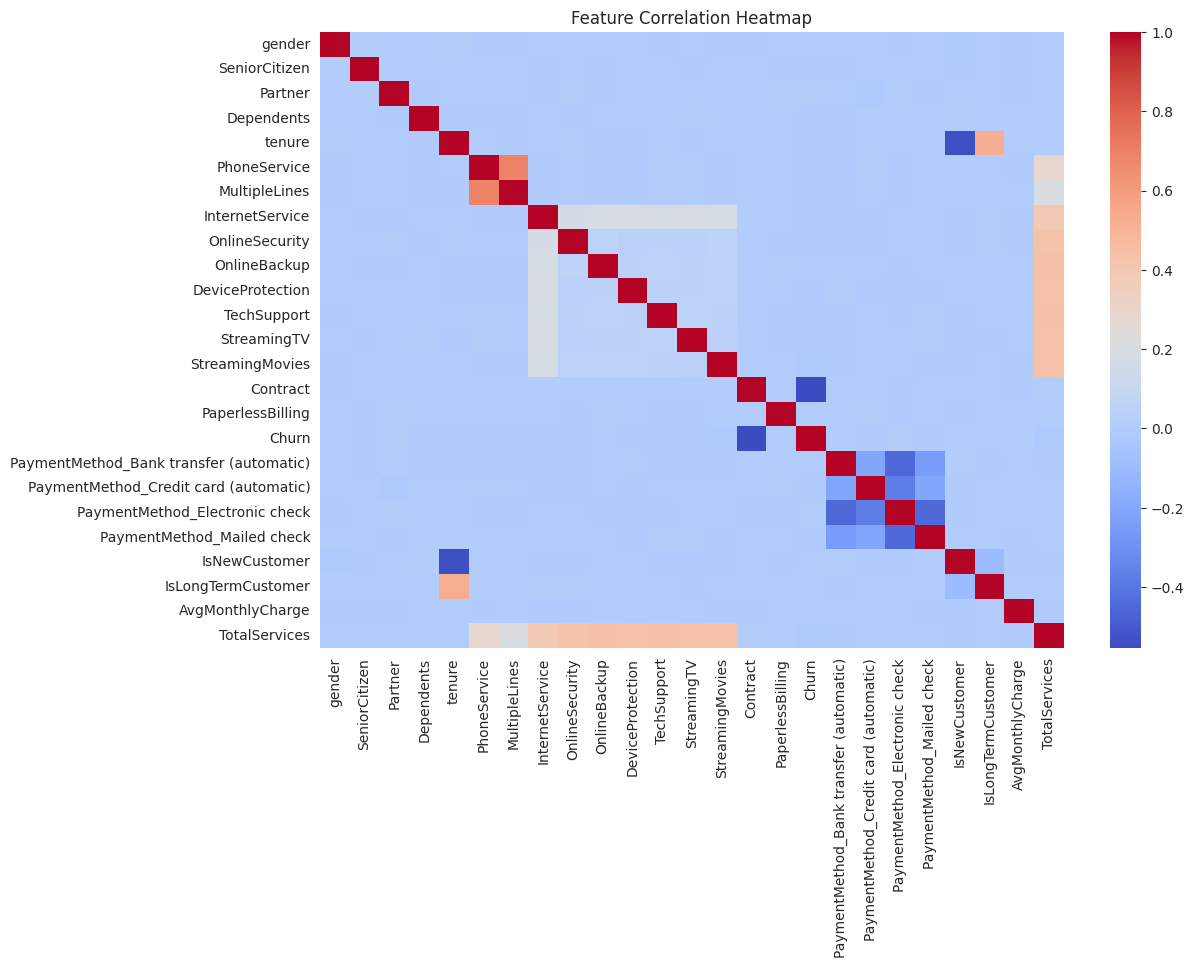
<br/><sub><i>Figure 9 — Feature Correlation Heatmap</i></sub>
</div>

Key observations:
- `Contract` shows the **strongest negative correlation** with `Churn` — longer contract = lower churn
- `MonthlyCharges`, `AvgMonthlyCharge`, and `TotalCharges` are highly inter-correlated (mathematically related)
- `tenure` negatively correlates with churn — longer customers stay longer

### 4.5 Churn Rate by Number of Services


<div align='center'>
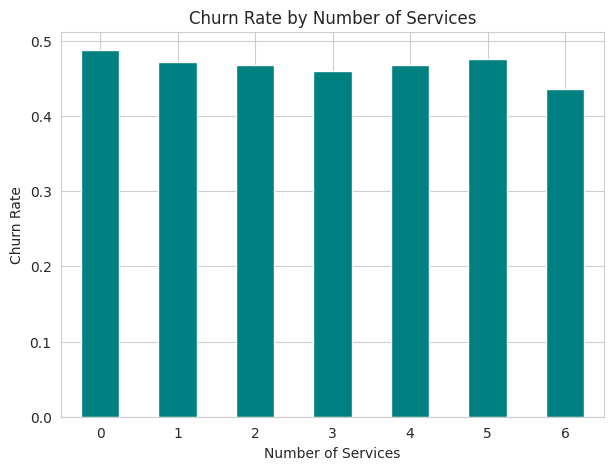
<br/><sub><i>Figure 10 — Churn Rate by Number of Subscribed Services</i></sub>
</div>

<div align='center'>
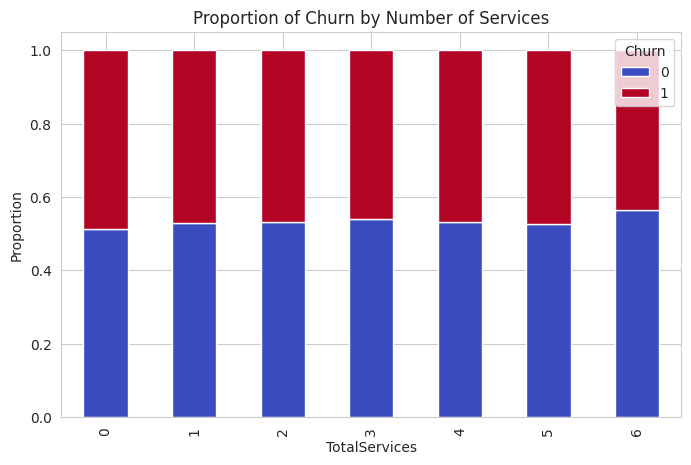
<br/><sub><i>Figure 11 — Proportion of Churn by Service Count (Stacked)</i></sub>
</div>

Churn rate remains stable across service counts (~43–49%), indicating that **which** services a customer has matters more than **how many**.

### 4.6 Monthly Charge Distribution by Churn


<div align='center'>
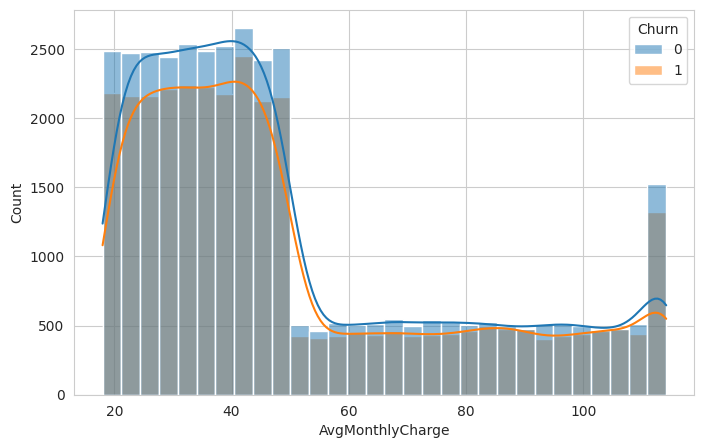
<br/><sub><i>Figure 12 — Average Monthly Charge Distribution by Churn</i></sub>
</div>

### 4.7 Churn by Internet Service Type


<div align='center'>
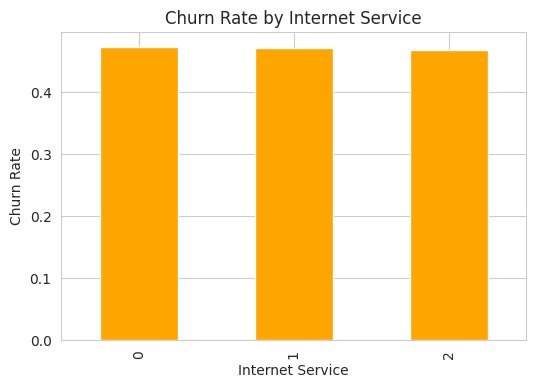
<br/><sub><i>Figure 13 — Churn Rate by Internet Service Type</i></sub>
</div>

Fiber Optic users show moderately higher churn, potentially reflecting higher prices or stronger competitor alternatives.

### 4.8 New vs Existing Customer Churn


<div align='center'>
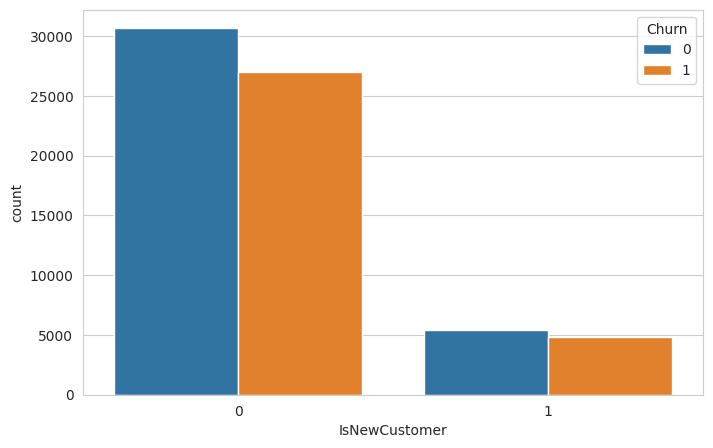
<br/><sub><i>Figure 14 — Churn: New vs Existing Customers</i></sub>
</div>

### 4.9 Top Features Correlated with Churn


<div align='center'>
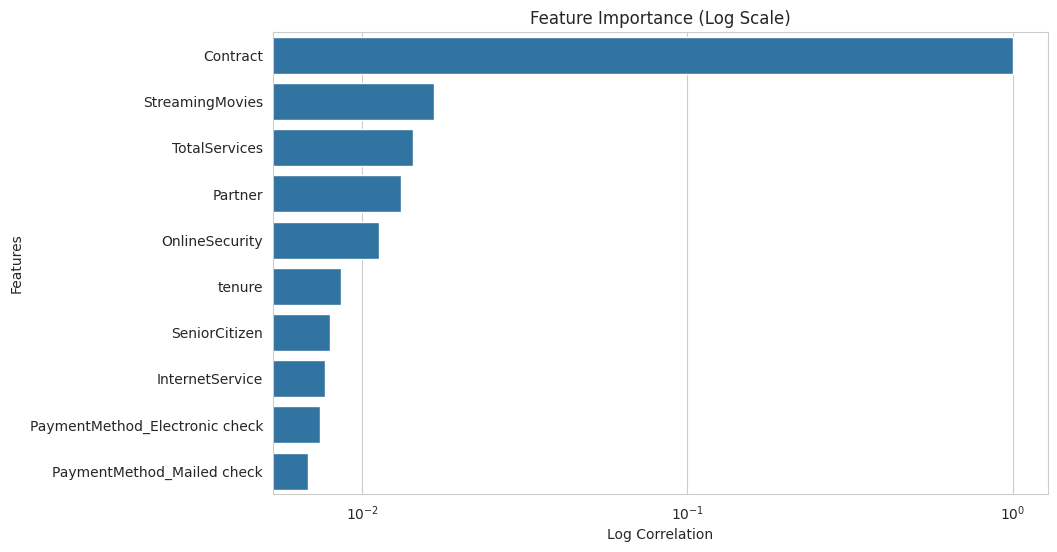
<br/><sub><i>Figure 15 — Top Features by Correlation with Churn</i></sub>
</div>

### 4.10 EDA Key Takeaways

| # | Finding | Business Implication |
|:---:|:---|:---|
| 1 | Contract type dominates churn behaviour | Convert month-to-month customers to annual plans |
| 2 | First 12 months are highest-risk | Invest in onboarding and early engagement |
| 3 | Fiber optic users churn more | Review service quality and competitive pricing |
| 4 | Service count has minimal effect | Bundle strategy alone is insufficient |
| 5 | Classes are near-balanced | No resampling needed |

---

## 5. Model Building & Evaluation

`notebooks/03_model_building.ipynb`

### 5.1 Experimental Setup

| Setting | Value |
|:---|:---|
| Train / Test Split | 80% / 20% |
| Stratification | Yes (preserves class ratio) |
| Training rows | 53,900 |
| Test rows | 13,476 |
| Random state | 42 |

### 5.2 Models Evaluated

**Logistic Regression** — Standard Pipeline with StandardScaler. Fast, interpretable, strong baseline for binary classification.

**Random Forest** — 200 trees ensemble. Handles non-linearity and feature interactions without scaling.

**Neural Network** — 3-layer deep network (128→64→32 units) with BatchNormalization, Dropout, and EarlyStopping. Trained with Adam optimizer for 100 epochs max.

| Layer | Units | Activation | Regularisation |
|:---|:---:|:---:|:---|
| Dense 1 | 128 | ReLU | BatchNorm + Dropout(0.3) |
| Dense 2 | 64 | ReLU | BatchNorm + Dropout(0.3) |
| Dense 3 | 32 | ReLU | Dropout(0.2) |
| Output | 1 | Sigmoid | — |

### 5.3 Results

| Model | Accuracy | Precision | Recall | F1 Score | AUC |
|:---|:---:|:---:|:---:|:---:|:---:|
| **Logistic Regression** | **77.0%** | 70.1% | **89.6%** | **0.7867** | 0.79 |
| Random Forest | 76.4% | 70.2% | 86.8% | 0.7761 | — |
| Neural Network | 76.8% | 69.7% | 89.5% | 0.7835 | **0.7912** |

All three models exceeded the F1 ≥ 0.70 success threshold ✅

### 5.4 Confusion Matrices


<div align='center'>
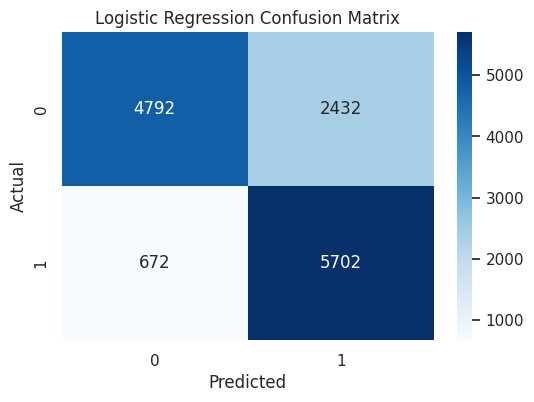
<br/><sub><i>Figure 16 — Confusion Matrix: Logistic Regression</i></sub>
</div>

<div align='center'>
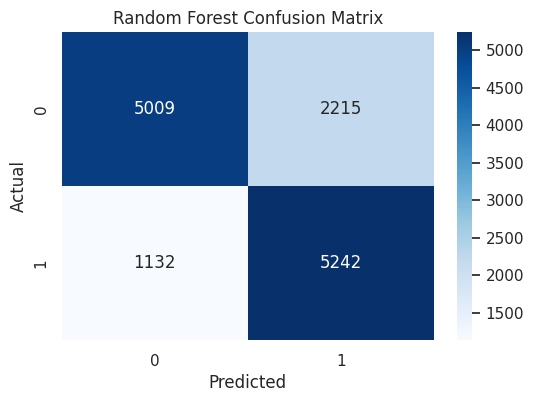
<br/><sub><i>Figure 17 — Confusion Matrix: Random Forest</i></sub>
</div>

<div align='center'>
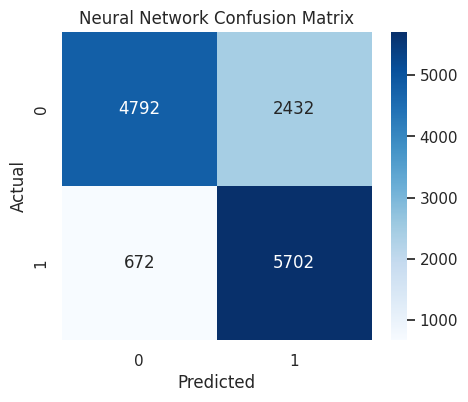
<br/><sub><i>Figure 18 — Confusion Matrix: Neural Network</i></sub>
</div>

### 5.5 Model Comparison


<div align='center'>
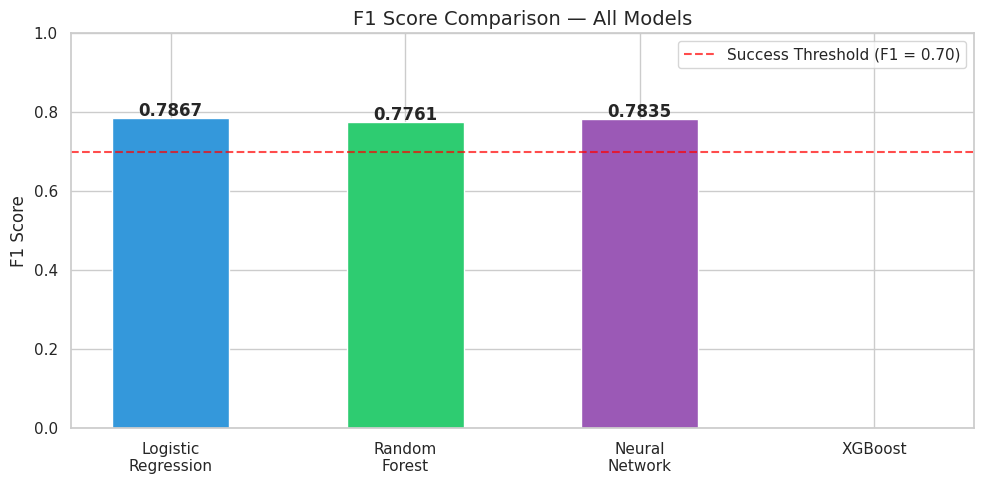
<br/><sub><i>Figure 19 — F1 Score Comparison Across All Models</i></sub>
</div>

<div align='center'>
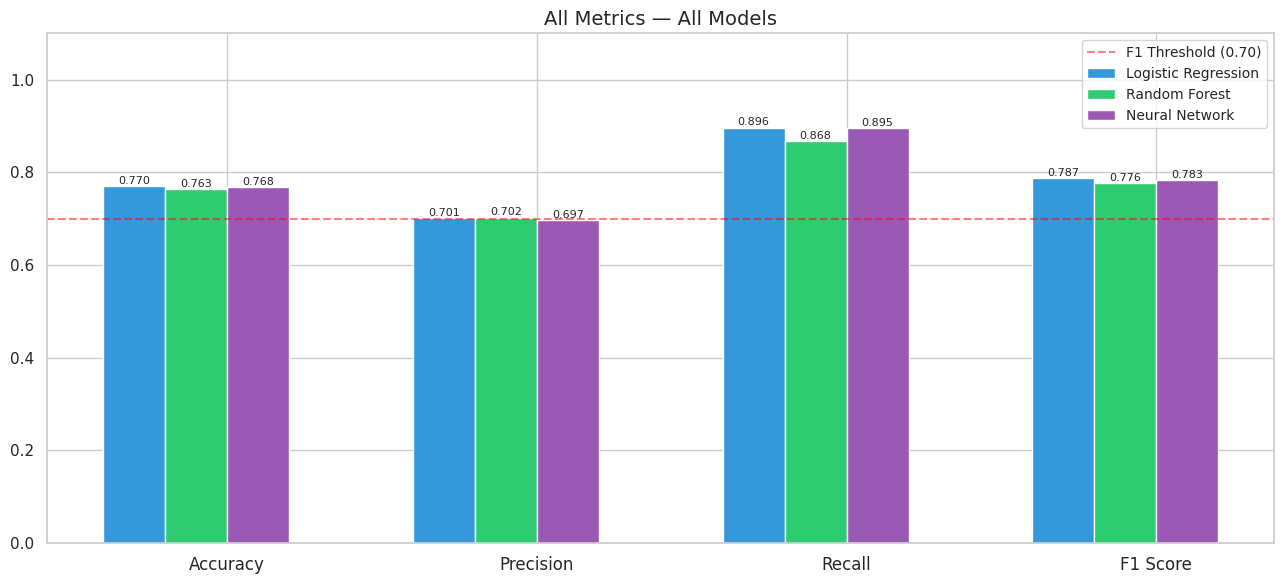
<br/><sub><i>Figure 20 — All Metrics Comparison Across All Models</i></sub>
</div>

### 5.6 Why All Models Converged

Further tuning was attempted on the Logistic Regression candidate:

| Technique | Outcome |
|:---|:---|
| `class_weight='balanced'` | No improvement — data near-balanced |
| `GridSearchCV` (C, penalty, solver) | Best: `C=0.01, l1` — no gain over default |
| Threshold tuning | Optimal: 0.71 — marginal difference only |
| XGBoost with `scale_pos_weight` | No improvement |
| 7 additional engineered features | No significant gain |

**Root cause:** The `Contract` feature dominated all tree-based models with ~90% feature importance. Every model learned the same rule: *"Month-to-month = likely to churn"*. The dataset had reached its **information ceiling** with the available features. New data sources (usage behaviour, complaint history, app activity) would be needed to push beyond F1 ≈ 0.79.

---

## 6. Final Results

### 6.1 Selected Model: Logistic Regression

| Criterion | Logistic Regression | Random Forest | Neural Network |
|:---|:---:|:---:|:---:|
| F1 Score | **0.7867** ✅ | 0.7761 | 0.7835 |
| Recall | **89.6%** ✅ | 86.8% | 89.5% |
| Interpretability | ✅ Full | ⚠️ Partial | ❌ Black box |
| Training speed | ✅ Seconds | ⚠️ Minutes | ❌ Minutes |
| Business explainability | ✅ Coefficients | ❌ Hard | ❌ Hard |

The simplest model achieved the best results — a textbook case of Occam's Razor in applied machine learning.

### 6.2 Business Impact on Test Set (13,476 customers)

| Prediction Outcome | Count | Business Meaning |
|:---|:---:|:---|
| ✅ True Positives | ~5,660 | Churners **correctly identified** for intervention |
| ❌ False Negatives | ~660 | Churners **missed** — lost revenue |
| ⚠️ False Positives | ~2,450 | Loyal customers **over-targeted** — wasted retention cost |
| ✅ True Negatives | ~4,706 | Loyal customers **correctly left alone** |

> The model catches **9 out of every 10 customers** who are about to churn.

### 6.3 Top Churn Risk Factors

| Rank | Feature | Effect |
|:---:|:---|:---|
| 1 | `Contract = Month-to-month` | Strongest positive predictor of churn |
| 2 | `tenure` (low) | Short tenure = higher churn probability |
| 3 | `MonthlyCharges` (high) | Higher bills increase churn likelihood |
| 4 | `InternetService = Fiber optic` | Elevated churn risk |
| 5 | `PaymentMethod = Electronic check` | Higher churn vs other methods |

---

## 7. Streamlit Application

`src/app.py` — A fully interactive prediction and analysis dashboard built with a custom dark-tech UI.

### 7.1 Pages

| Page | Content |
|:---|:---|
| 🏠 **Overview** | KPI metrics (total customers, churn rate, avg charge), churn donut chart, contract-type comparison, key insight cards |
| 📊 **Data Explorer** | Tenure & charge histograms, full correlation heatmap, per-feature deep dive (histogram + boxplot) |
| 🤖 **Model Performance** | Side-by-side metrics table, grouped bar chart, confusion matrices, ROC curve comparison |
| 🔮 **Predict Customer** | Full input form → real-time churn probability with visual risk bar + risk factor breakdown panel |

### 7.2 Technical Stack

| Component | Technology |
|:---|:---|
| UI Framework | Streamlit + custom CSS (Space Mono + DM Sans) |
| Charts | Matplotlib + Seaborn (dark theme) |
| Models | Scikit-Learn Pipeline (StandardScaler + LR / RF) |
| Data | GitHub raw URL with `@st.cache_data` caching |

---

## 8. Conclusions & Recommendations

### 8.1 Summary

| Deliverable | Status |
|:---|:---:|
| Working churn classifier | ✅ |
| F1 ≥ 0.70 | ✅ 0.7867 |
| Recall ≥ 0.80 | ✅ 89.6% |
| Multi-model comparison (LR + RF + NN) | ✅ |
| Interactive Streamlit deployment | ✅ |

### 8.2 Business Recommendations

| Priority | Action | Target |
|:---:|:---|:---|
| 🔴 Critical | Incentivise switch to annual contracts | Month-to-month customers |
| 🔴 Critical | Launch onboarding retention programme | `tenure < 6 months` |
| 🟡 High | Discount security/support bundles | Customers with 0–1 add-ons |
| 🟡 High | Review Fiber Optic pricing | High-charge fiber users |
| 🟢 Medium | Deploy monthly model scores to CRM | All active customers |

### 8.3 Limitations & Future Work

| Limitation | Suggested Improvement |
|:---|:---|
| No behavioural data (calls, app usage) | Add usage patterns as features |
| Static snapshot — no time dimension | Rolling-window features across billing periods |
| Models plateau at F1 ≈ 0.79 | New data sources required |
| `Contract` dominates all models | Explore interaction features |
| App trains models on demand | Serialise with `joblib` for production |

---

## 9. References

1. IBM Telco Customer Churn Dataset — [Kaggle](https://www.kaggle.com/blastchar/telco-customer-churn)
2. Project Repository — [github.com/linda-bsharat/telco-customer-churn-prediction](https://github.com/linda-bsharat/telco-customer-churn-prediction)
3. Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12, pp. 2825–2830.
4. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3rd ed.). O'Reilly.
5. McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly.
6. Abadi et al. (2016). *TensorFlow: A System for Large-Scale Machine Learning*. OSDI.
7. Streamlit Inc. (2024). *Streamlit Documentation*. https://docs.streamlit.io

---

<div align='center' style='padding:24px; color:#6c757d; font-size:0.85em; border-top:1px solid #dee2e6; margin-top:20px;'>

📡 <b>Telco Customer Churn Prediction</b> &nbsp;·&nbsp; IBT × GGateway Data Science Bootcamp &nbsp;·&nbsp; March 2026
<br/><br/>
Ruba Halabi &nbsp;·&nbsp; Linda Bsharat &nbsp;·&nbsp; Ibrahim Kilani &nbsp;·&nbsp; Naser Abdalsalam &nbsp;·&nbsp; Ahmad Abu Alhlawa
<br/>
Mentors: Daniel Rubi &nbsp;·&nbsp; Dr. Ramiz

</div>